In [1]:
%matplotlib ipympl
#imported from Pranav Sanghavi's notebook
import glob
import os
import time
import h5py
import matplotlib.pylab as plt
import numpy as np
import numpy.ma as ma
from matplotlib.offsetbox import AnchoredText
from matplotlib.pylab import colorbar
#from skrf import Network, Frequency
from platform import python_version
import math
import psutil
import matplotlib.cm as cm
from scipy.stats import iqr
import pytz,pickle,yaml,sys
#importing for Will's extract_source_pulses function
from scipy import interpolate
import datetime
from scipy.signal import square
from scipy.stats import pearsonr
import pandas
#import time_utils as tu   ###Will's time utils.  in WVURAIL if need
from mpl_toolkits.axes_grid1 import make_axes_locatable

#import the beamcals module, use forked repository (not original):
#sys.path.insert(0, '../../classes/')
#import corr, concat, drone
#import plotting_utils as pu
#import fitting_utils as fu
#import geometry_utils as gu
#import time_utils as tu
#import site_utils as si
#gbosite=si.Site('../../metadata/TONE_d5_config.npz')
#gbosite=si.Site('/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/GBO_acq/TONE_d5_config.npz')


#np.set_printoptions(threshold=np.inf)


style = 'fast'
tick_dir = 'in'
plt.style.use(style)
plt.rcParams['xtick.direction'] = tick_dir
plt.rcParams['ytick.direction'] = tick_dir
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['font.size'] = 15
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.5
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif"})

###################################################################################
# Analog chain labels
###################################################################################

#pathtoacfile = "/home/observer/tone_jupyter/anachainz.csv"
#ac = np.genfromtxt(pathtoacfile, delimiter=",", names=True,
#                   dtype=(int, int, 'U5', 'U5', int, 'U2', int))
#inputs = ac['feed']

def get_beam_fwhm(d=6.0, nu=600):
    fwhm = constants.c/(nu*1e6)/d   # lambda/D
    return np.rad2deg(fwhm * 1.22)

def gaussian(x, a, mean, sigma):
    val = a * np.exp(-(x - mean)**2 / sigma**2)
    return val

def scale_zero_one(x):
    return (x - x.min())/(x.max() - x.min())

def seconds_to_degrees(seconds, declination=22.0145):
    """
        This function converts seconds to degrees of sky motion at a latitude
        default TONE latitude -- default for crab.
    """
    return seconds * np.cos(np.deg2rad(declination)) / 240

def read_corr_mode_h5(file_path, f_start=None, f_stop=None):
    """
        This function reads all hdf5 files.
    """
    class correlator_data:
        def __init__(self, vis, time, sat, index_map):
            self.vis = vis
            self.time = time
            self.sat = sat
            self.freq = index_map["freq"][:]
            self.prod = index_map['prod'][:]
    files = glob.glob(file_path + "*[!.lock]")
    files.sort()

    #grab different sets of files.
    if f_start is not None:
        if f_stop is not None:
            files = files[f_start:f_stop]
        else:
            files = files[f_start:]
    if f_start is None:
        if f_stop is not None:
            files = files[:f_stop]

    try:
        t = 0
        for x in files:
            print(f"Reading File: {x}")
            f = h5py.File(x, "r")
            index_map = f['index_map']
            if(t == 0):
                vis = f['vis'][:]
                time = index_map['time'][:]
                sat = f['sat'][:]
                print("Appended vis data and time stream from %s" % (x))
                t = t + 1
            else:
                time = np.append(time, index_map['time'][:])
                vis = np.append(vis, f['vis'][:], axis=0)
                sat = np.append(sat, f['sat'][:], axis=0)
                print("Appended vis data and time stream from %s" % (x))

        return correlator_data(
            vis,
            time,
            sat,
            index_map
        )
    finally:
        print("Done!!!!!!!")

def get_mag_phase(corr_dat):
    """
        This function returns magnitude and phase in degrees of correlations.
    """
    return np.absolute(corr_dat), np.rad2deg(np.angle(corr_dat))

def plot_waterfall_corr_data(data, corr_indices):
    """
        This function plots waterfall across 1024 frequency channels.
        Frequency range: 400-800MHz
    """
    fig=plt.figure(figsize=(20,20))
    dim1 = math.floor(math.sqrt(len(corr_indices)))
    dim2 = math.ceil(len(corr_indices)/dim1)
    for i,auto in enumerate(corr_indices):
        ax=plt.subplot(dim1, dim2, i + 1)
        wfall = data[:, :, auto] # auto -> corr index
        im=plt.imshow(wfall, vmin = np.nanpercentile(wfall,5), vmax =np.nanpercentile(wfall,95), cmap='gnuplot2', aspect='auto')
        plt.xlabel("freq index")
        plt.ylabel("time index")
        plt.title(f"corr {corr_data.prod[auto]}")
        divider=make_axes_locatable(ax)
        cax=divider.append_axes("right", size="5%", pad=0.05)
        cbar=fig.colorbar(im,cax=cax)
        cbar.set_label('Power [$ADU^2$]')
    plt.tight_layout()

def plot_freq_channel_corr_data(pow_mag, freq_index, freq, corr_indices):
    """
        This function plots phase for a given frequency index for given time window.
    """
    plt.figure(figsize=(20, 20))
    dim1 = math.floor(math.sqrt(len(corr_indices)))
    dim2 = math.ceil(len(corr_indices)/dim1)
    for index, corr_index in enumerate(corr_indices):
            plt.subplot(dim1, dim2, index + 1)
            plt.title(f"Corr: {corr_data.prod[corr_index]}")
            plt.plot(pow_mag[:, freq_index, corr_index])
    plt.suptitle(f"Frequency {freq} MHz")
    plt.tight_layout()

def plot_phase_corr_data(pow_phase, corr_indices, t_ind_arr):
    """
        This function plots phase for a given time index across frequency range of 400-800MHz.
    """
    for i, t_index in enumerate(t_ind_arr):
        fig= plt.figure(figsize=(25, 10))
        dim1 = math.floor(math.sqrt(len(corr_indices)*len(t_ind_arr)))
        dim2 = math.ceil(len(corr_indices)*len(t_ind_arr)/dim1)
        for index, corr_index in enumerate(corr_indices):
                ax = plt.subplot(dim2, dim1, i + 1)
                ax.plot(pow_phase[t_index,:, corr_index], c=colorsarr[300], label=f'time index {t_index}')
                ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
                plt.xlabel(f"frequency index")
                plt.ylabel(f"phase (degrees)")
                plt.title(f"Corr: {corr_data.prod[corr_index]}")
                #plt.suptitle(f"Correlated noise phase")
        plt.tight_layout()

def chunk_lists_(data_):
    """
        This function makes sublists of time indices of individual ON/OFF pulses.
        Returns list of lists
    """

    consecutive_list = []

    for chunks in range(len(data_)):
        try:
            if data_[chunks + 1] - data_[chunks] == 1:

                #check if index is already in list:
                if data_[chunks] not in consecutive_list:
                    consecutive_list.append(data_[chunks])
                #add last index too
                consecutive_list.append(data_[chunks + 1])

            else:
                yield consecutive_list
                consecutive_list = []

        except Exception:
            pass

    yield consecutive_list


## Reading correlator file --

In [2]:
#f = h5py.File("/Volumes/EXTRSSD/CRS_data/20260224T130143Z_pathfinder_corr8/0.hdf5","r")
#f = h5py.File("C:\\Users\\kband\\Downloads\\0-001.hdf5","r")
###Forward and back.
f = h5py.File("C:\\Users\\kband\\data\\gbo\\junejuly2026\\drone_flight3_NWNE_grid_jun30_1645\\8.hdf5","r")
#f2 = h5py.File("F:\\crs_chamber_data\\corr_data\\20260529-130944_anechoicchamber_corr8\\0.hdf5","r")
print(list(f.keys()))
#print(f['adc'])
print(f['counts'])
#print(f['fft'])
print(list(f['index_map']))
print(f['sat'])
#print(f['stats'])
print(f['vis']) # 256 time indices, 8192 freq indices, 36 visibility products

['counts', 'index_map', 'sat', 'vis']
<HDF5 dataset "counts": shape (1000,), type "<u4">
['freq', 'prod', 'time']
<HDF5 dataset "sat": shape (1000, 8192, 36), type "<c8">
<HDF5 dataset "vis": shape (1000, 8192, 36), type "<c16">


In [7]:
times = f['index_map']['time']
#times2 = f2['index_map']['time']

In [3]:
prod_map = [[0, 0],
[0, 1],
[0, 2],
[0, 3],
[1, 1],
[1, 2],
[1, 3],
[1, 4],
[2, 2],
[2, 3],
[2, 4],
[2, 5],
[3, 3],
[3, 4],
[3, 5],
[3, 6],
[4, 4],
[4, 5],
[4, 6],
[4, 7],
[5, 5],
[5, 6],
[5, 7],
[0, 4],
[6, 6],
[6, 7],
[0, 5],
[1, 5],
[7, 7],
[0, 6],
[1, 6],
[2, 6],
[0, 7],
[1, 7],
[2, 7],
[3, 7]]

In [4]:
prod_map[0]

[0, 0]

In [5]:
# 0-> 00  (local noise auto)
# 1-> 01  (cross with bicolog)
# 2 -> 02 (cross with first pol)
# 3 -> 03 (cross with second pol)
# 4 -> 11 (bicolog auto)
# 8 -> 22 (first pol auto)
# 12 -> 33 (second pol auto)


In [8]:
(times[999] - times[0])/1000

np.float64(0.10354541397094727)

In [9]:
fpga_counts = f['counts']

In [10]:
times.shape

(1000,)

In [7]:
one_frame = 4096/1600000000*16384*2

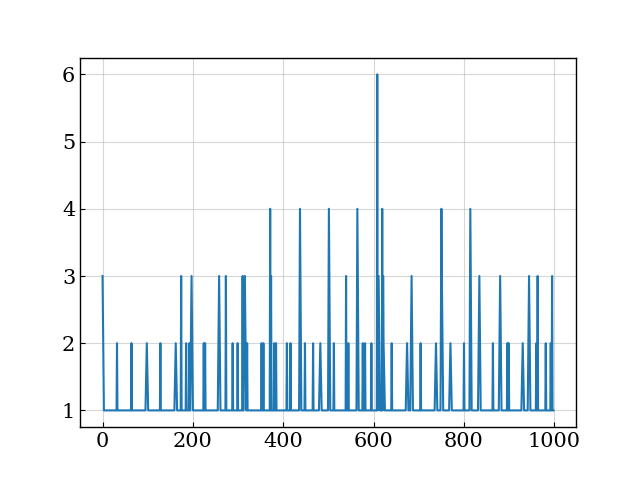

In [11]:
plt.figure()
plt.plot(np.round((times[1:]-times[:-1])/0.083))

In [43]:
freqs = f['index_map']['freq']

In [12]:
noise_source = f['vis'][:,:,0]
corr_bico = f['vis'][:,:,1]
corr_p1 = f['vis'][:,:,2]
corr_p2 = f['vis'][:,:,3]
bico_auto = f['vis'][:,:,4]
p1_auto = f['vis'][:,:,8]
p2_auto = f['vis'][:,:,12]

In [14]:
np.abs(corr_bico[500,3500])

np.float64(19073.27211046914)

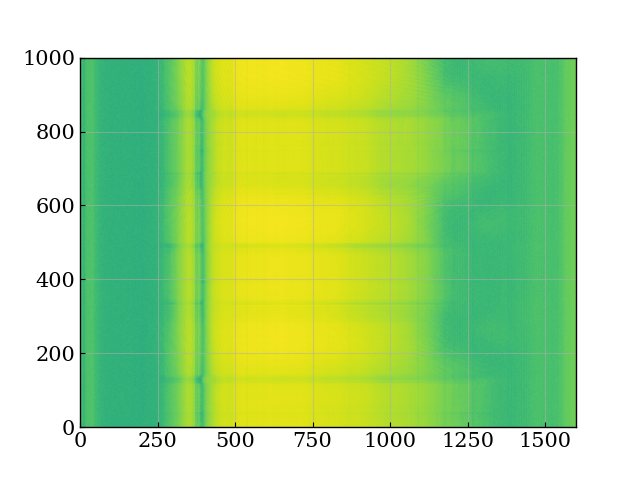

In [17]:
#extent=[left, right, bottom, top]
plt.figure()
plt.imshow(10*np.log10(np.abs(corr_bico[:,:])), extent=[0, 1600, 0, 1000], aspect='auto')
plt.show()

C:\Users\kband\AppData\Local\Temp\ipykernel_56384\2094561815.py:2: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(10*np.log10(np.abs(corr_p1[:,:])), extent=[0, 1600, 0, 1000], aspect='auto')


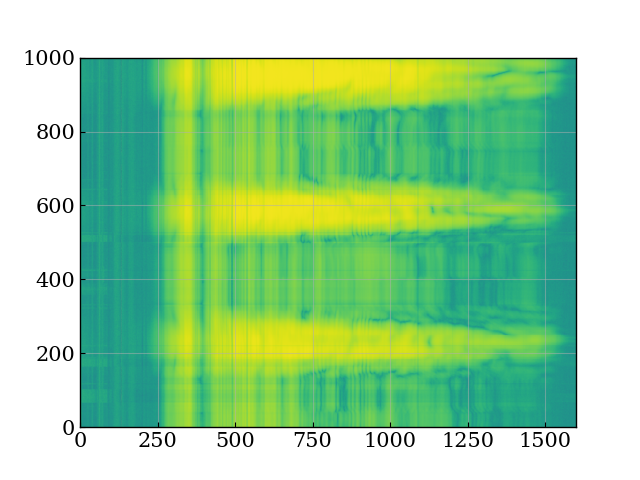

In [16]:
plt.figure()
plt.imshow(10*np.log10(np.abs(corr_p1[:,:])), extent=[0, 1600, 0, 1000], aspect='auto')
plt.show()

C:\Users\kband\AppData\Local\Temp\ipykernel_56384\180007879.py:2: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(10*np.log10(np.abs(corr_p2[:,:])), extent=[0, 1600, 0, 1000], aspect='auto')


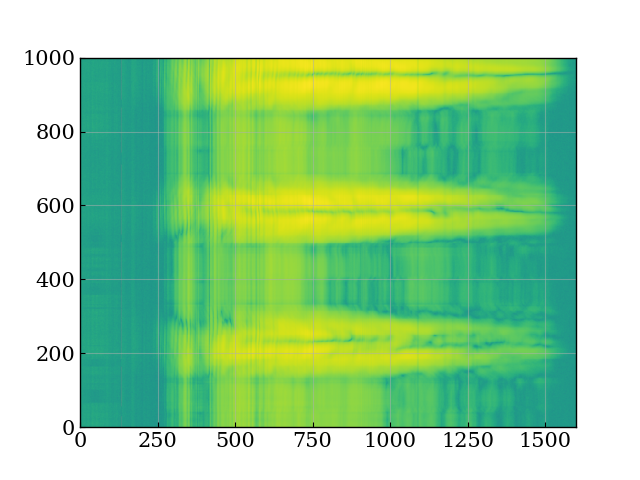

In [18]:
plt.figure()
plt.imshow(10*np.log10(np.abs(corr_p2[:,:])), extent=[0, 1600, 0, 1000], aspect='auto')
plt.show()

In [19]:
f2 = h5py.File("C:\\Users\\kband\\data\\gbo\\junejuly2026\\drone_flight3_NWNE_grid_jun30_1645\\9.hdf5","r")

In [20]:
corr_p1_2 = f2['vis'][:,:,2]

In [21]:
corr_p1_2.shape

(1000, 8192)

In [28]:
ddd = np.concatenate((corr_p1, corr_p1_2))

In [26]:
ddd = np.concatenate((ddd, corr_p1_2))

In [27]:
ddd.shape

(3000, 8192)

C:\Users\kband\AppData\Local\Temp\ipykernel_56384\2809229289.py:2: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(10*np.log10(np.abs(ddd[:,:])), extent=[0, 1600, 0, 2000], aspect='auto')


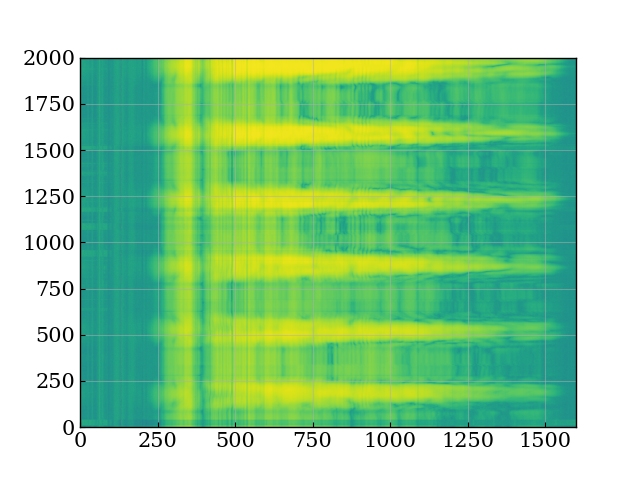

In [30]:
plt.figure()
plt.imshow(10*np.log10(np.abs(ddd[:,:])), extent=[0, 1600, 0, 2000], aspect='auto')
plt.show()

In [56]:
freqs[3500]

np.float64(683.59375)

In [31]:
def get_corr_product(files, corr_prod=2):
    n = len(files)
    f = h5py.File(files[0],"r")
    times = f['index_map']['time']
    corr_p = f['vis'][:,:,corr_prod]
    files = files[1:]
    for file in files:
        f = h5py.File(file,"r")
        times1 = f['index_map']['time']
        corr_p1 = f['vis'][:,:,corr_prod]
        corr_p = np.concatenate((corr_p, corr_p1))
        times = np.concatenate((times, times1))
    return times, corr_p
            

        

In [33]:
file_list = glob.glob("C:\\Users\\kband\\data\\gbo\\junejuly2026\\drone_flight3_NWNE_grid_jun30_1645\\*.hdf5")
###Windows style
#file_list = glob.glob('C:\\Users\\kband\\OneDrive - West Virginia University\\ipython_notebooks\\dns_RFI_testing\\CRS*')
file_list.sort()

In [39]:
mid1_files = file_list[-7:]

In [48]:
mid1_files

['C:\\Users\\kband\\data\\gbo\\junejuly2026\\drone_flight3_NWNE_grid_jun30_1645\\3.hdf5',
 'C:\\Users\\kband\\data\\gbo\\junejuly2026\\drone_flight3_NWNE_grid_jun30_1645\\4.hdf5',
 'C:\\Users\\kband\\data\\gbo\\junejuly2026\\drone_flight3_NWNE_grid_jun30_1645\\5.hdf5',
 'C:\\Users\\kband\\data\\gbo\\junejuly2026\\drone_flight3_NWNE_grid_jun30_1645\\6.hdf5',
 'C:\\Users\\kband\\data\\gbo\\junejuly2026\\drone_flight3_NWNE_grid_jun30_1645\\7.hdf5',
 'C:\\Users\\kband\\data\\gbo\\junejuly2026\\drone_flight3_NWNE_grid_jun30_1645\\8.hdf5',
 'C:\\Users\\kband\\data\\gbo\\junejuly2026\\drone_flight3_NWNE_grid_jun30_1645\\9.hdf5']

In [40]:
tt, p1 = get_corr_product(mid1_files, 2)

C:\Users\kband\AppData\Local\Temp\ipykernel_56384\1166135642.py:2: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(10*np.log10(np.abs(p1[:,:])), extent=[0, 1600, 0, 2000], aspect='auto')


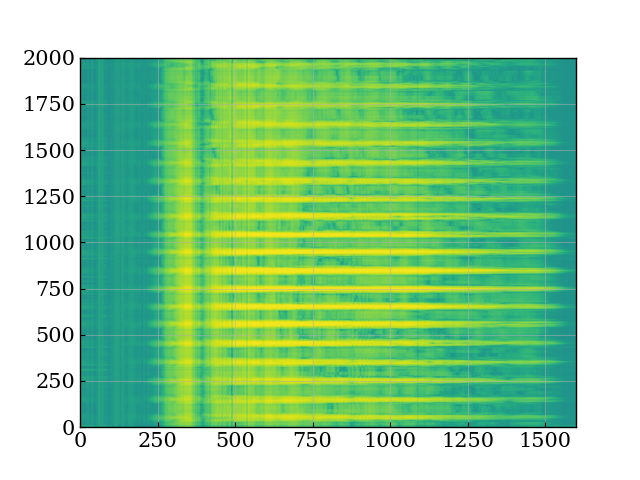

In [41]:
plt.figure()
plt.imshow(10*np.log10(np.abs(p1[:,:])), extent=[0, 1600, 0, 2000], aspect='auto')
plt.show()

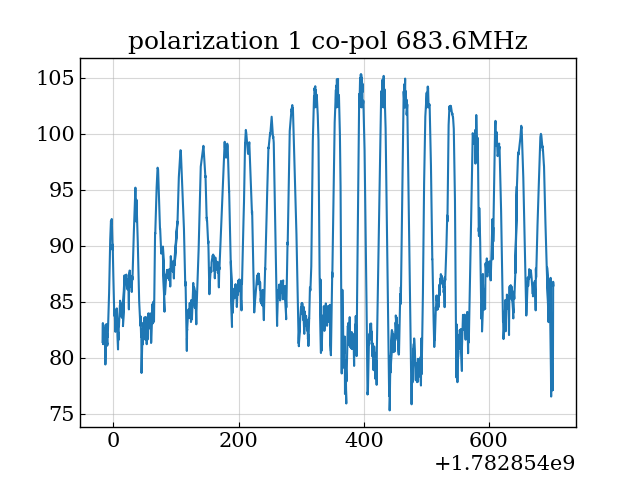

In [57]:
plt.figure()
plt.plot(tt,20*np.log10(np.abs(p1[:,3500])))
plt.title("polarization 1 co-pol 683.6MHz")
#plt.savefig('co-pol_flight1.pdf')
plt.show()

In [51]:
tt2, p2 = get_corr_product(mid1_files, 3)

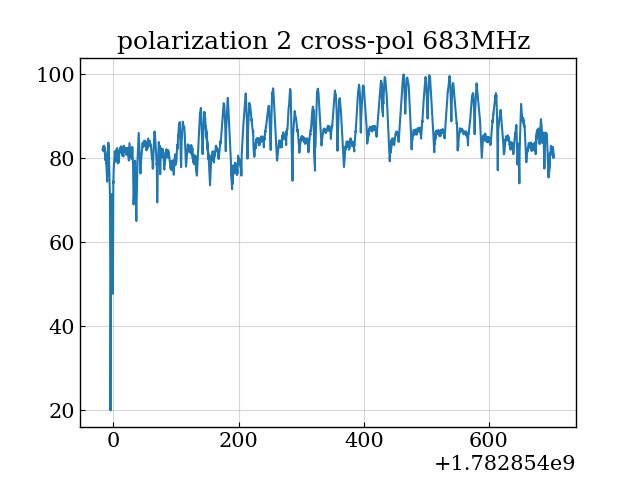

In [58]:
plt.figure()
plt.plot(tt,20*np.log10(np.abs(p2[:,3500])))
plt.title("polarization 2 cross-pol 683MHz ")
plt.savefig('cross-pol_flight1.pdf')
plt.show()

In [53]:
tt3, bico = get_corr_product(mid1_files, 1)

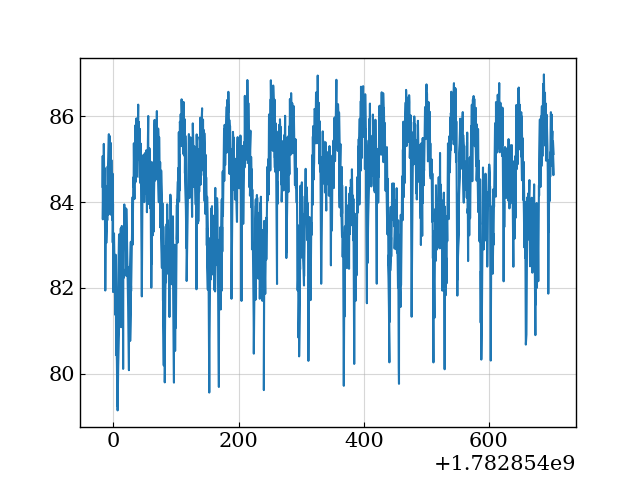

In [54]:
plt.figure()
plt.plot(tt3,20*np.log10(np.abs(bico[:,3500])))
plt.show()

In [44]:
freqs[3500]

np.float64(683.59375)

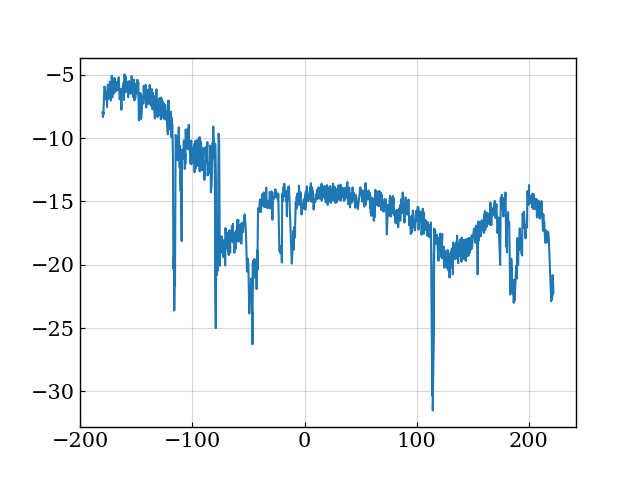

In [17]:
plt.figure()
plt.plot(ttt,20*np.log10(np.abs(corr01[:,1540]))-97.5)
plt.show()

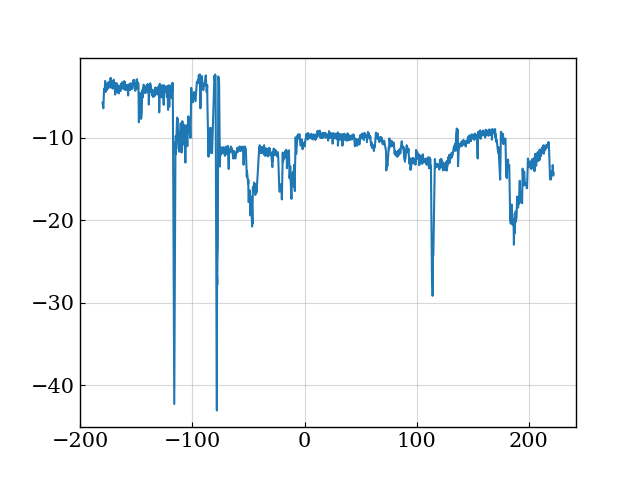

In [18]:
plt.figure()
plt.plot(ttt,20*np.log10(np.abs(corr01[:,2050]))-97.5)
plt.show()

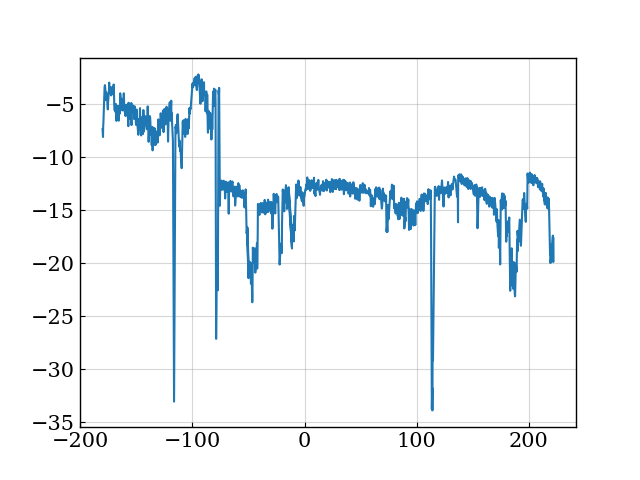

In [19]:
plt.figure()
plt.plot(ttt,20*np.log10(np.abs(corr01[:,2050+510]))-97.5)
plt.show()

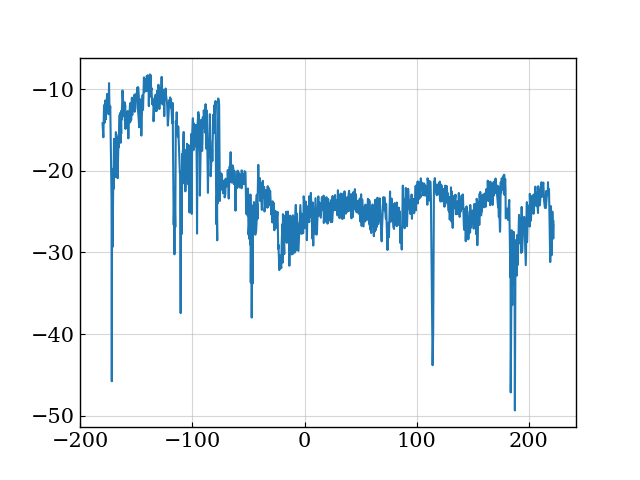

In [20]:
plt.figure()
plt.plot(ttt,20*np.log10(np.abs(corr01[:,2050+2*510]))-97.5)
plt.show()

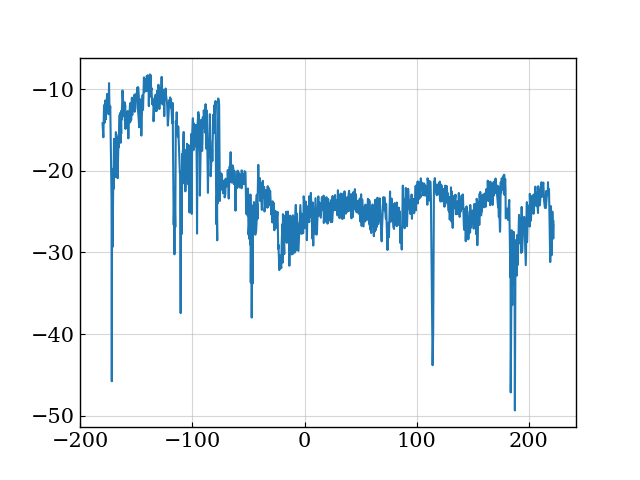

In [16]:
plt.figure()
plt.plot(ttt,20*np.log10(np.abs(corr01[:,2050+2*510]))-97.5)
plt.show()

In [21]:
freqs[2050+6*511]

NameError: name 'freqs' is not defined

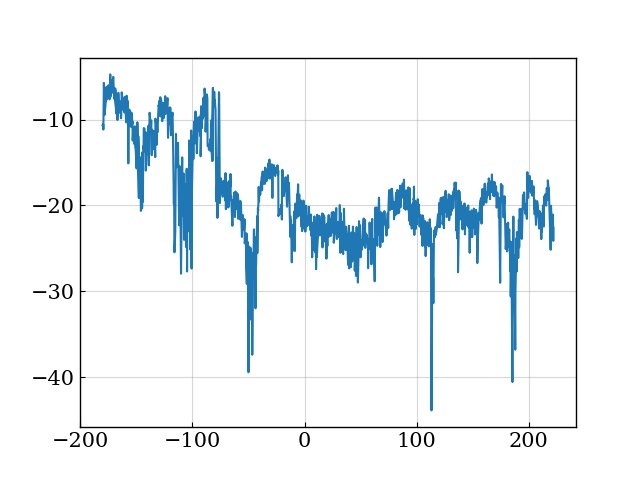

In [22]:
plt.figure()
plt.plot(ttt,20*np.log10(np.abs(corr01[:,2050+6*511]))-94.5)
plt.show()

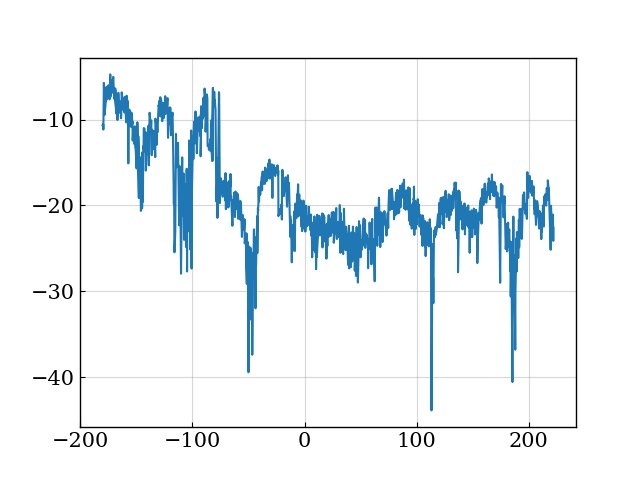

In [23]:
plt.figure()
plt.plot(ttt,20*np.log10(np.abs(corr01[:,2050+6*511]))-94.5)
plt.show()

In [49]:
ttt[2089]

np.float64(180.5950222015381)

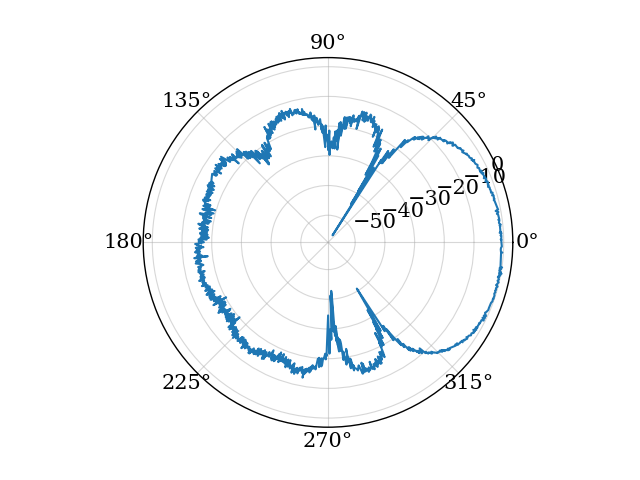

In [51]:
plt.figure()
plt.polar(ttt[:2089]*np.pi/180,20*np.log10(np.abs(corr01[:2089,2050+6*511]))-94.5)
plt.show()

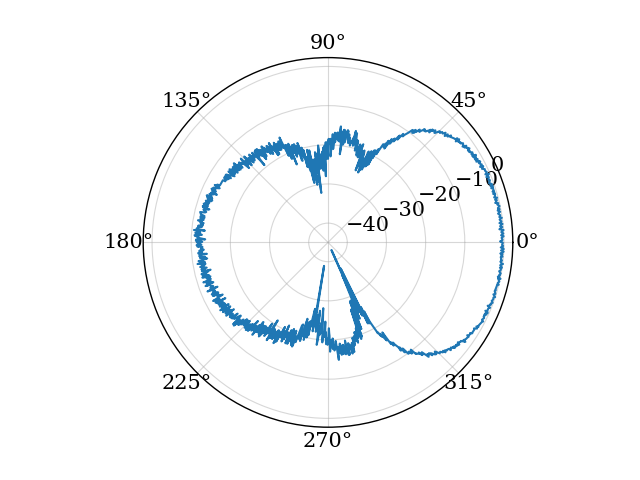

In [54]:
plt.figure()
plt.polar(ttt[:2089]*np.pi/180,20*np.log10(np.abs(corr01[:2089,2050+5*511]))-94.5)
plt.show()

C:\Users\kband\AppData\Local\Temp\ipykernel_48124\735801847.py:1: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


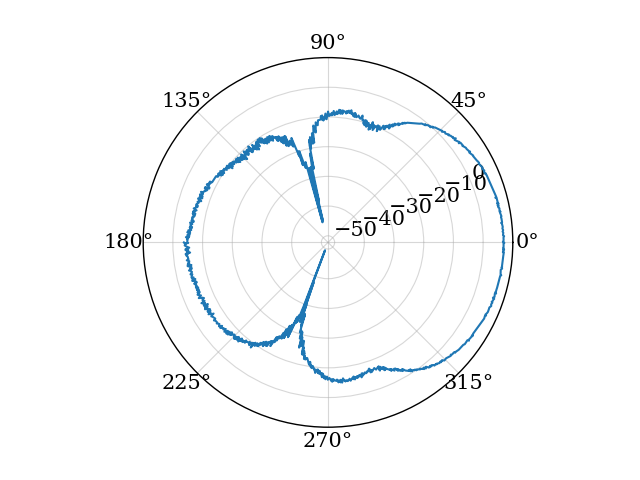

In [53]:
plt.figure()
plt.polar(ttt[:2089]*np.pi/180,20*np.log10(np.abs(corr01[:2089,2050+4*511]))-94.5)
plt.show()

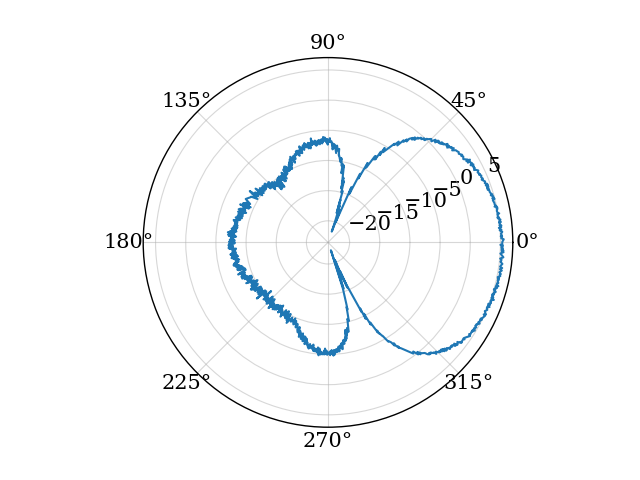

In [55]:
plt.figure()
plt.polar(ttt[:2089]*np.pi/180,20*np.log10(np.abs(corr01[:2089,2050+3*511]))-94.5)
plt.show()

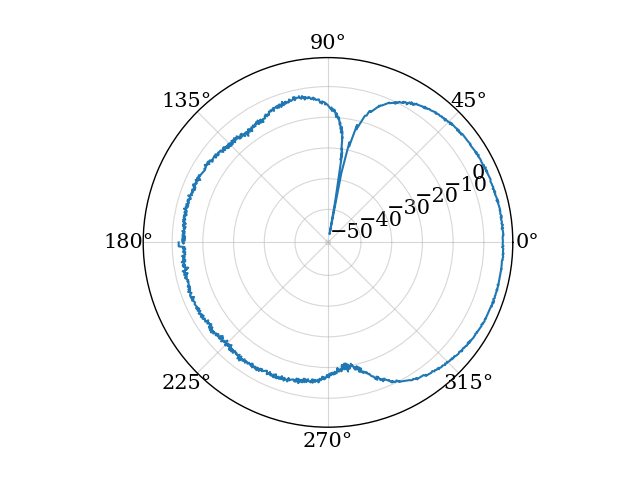

In [56]:
plt.figure()
plt.polar(ttt[:2089]*np.pi/180,20*np.log10(np.abs(corr01[:2089,2050+2*511]))-94.5)
plt.show()